# Fig 2: Insula AIC / PIC


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path
import pandas as pd
import seaborn as sns
import mne
import pyvista as pv
from mne.viz import Brain
from mne_bids import BIDSPath
from scipy.spatial import cKDTree
from tqdm import tqdm
import xarray as xr


In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')


Using notebook 3d backend.


## Load significant HGA


In [10]:
task = [
    'PhonemeSequence',
    'LexicalDelay',
    'PictureNaming',
    'LexicalNoDelay'
]

ref = 'bipolar'
atlas = 'hammers'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})({atlas})',
            datatype='HGA',
            suffix='time',
            check=False,
        ).match()
    )

if not hga_paths:
    raise FileNotFoundError(
        f'No time CSVs under results/{{task}}({ref})({atlas})/ for tasks={task}'
    )

HGAs = pd.concat(
    [pd.read_csv(path) for path in tqdm(hga_paths, desc='load time')],
    ignore_index=True,
)

HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'
HGAs['phase'] = HGAs['phase'].str.lower()

# Hammers ROI groupings (same convention as vizpub fig1)
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'STGp', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'STGa', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'

print(f"AIC row count: {(HGAs['roi'] == 'AIC').sum()}")
print(f"PIC row count: {(HGAs['roi'] == 'PIC').sum()}")
print(f"AIC unique channels: {HGAs.loc[HGAs['roi'] == 'AIC', 'channel'].nunique()}")
print(f"PIC unique channels: {HGAs.loc[HGAs['roi'] == 'PIC', 'channel'].nunique()}")

HGAs.head()


load time: 100%|██████████| 1491/1491 [00:33<00:00, 44.50it/s]


AIC row count: 396480
PIC row count: 162240
AIC unique channels: 206
PIC unique channels: 100


,time,channel,value,mask,subject,description,task,phase,modality,label,...,y1_template,z1_template,x2_template,y2_template,z2_template,contact_1,contact_2,contact_1_label,contact_2_label,mix
0,-1.000000,D0019_RLOS2-3,-0.050144,False,D0019,Repeat,PhonemeSequence,delay,sound,PL supramarginal gyrus R,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,0,0,False
1,-0.992188,D0019_RLOS2-3,-0.096867,False,D0019,Repeat,PhonemeSequence,delay,sound,PL supramarginal gyrus R,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,0,0,False
2,-0.984375,D0019_RLOS2-3,-0.125324,False,D0019,Repeat,PhonemeSequence,delay,sound,PL supramarginal gyrus R,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,0,0,False
3,-0.976562,D0019_RLOS2-3,-0.123982,False,D0019,Repeat,PhonemeSequence,delay,sound,PL supramarginal gyrus R,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,0,0,False
4,-0.968750,D0019_RLOS2-3,-0.100060,False,D0019,Repeat,PhonemeSequence,delay,sound,PL supramarginal gyrus R,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,0,0,False


## Panel A: Temporal waveforms (AIC + PIC)


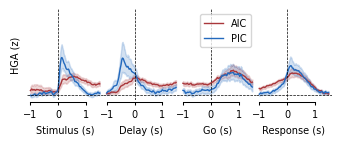

In [23]:
rois = ['AIC', 'PIC']
colors = [red, blue]

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality == 'sound')
    & (HGAs.roi.isin(rois))
    & (HGAs.subject != 'D0121')
]

phases = ['stimulus', 'delay', 'go', 'response']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2.5 * len(phases) * cm, 3 * cm))
plt.subplots_adjust(wspace=0)

for ax, phase in zip(axes, phases):
    legend = True if ax == axes[-2] else False
    sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='roi',
        hue_order=rois,
        ax=ax,
        palette=colors,
        legend=legend,
        lw=1,
    )
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)

    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)

    sns.despine(ax=ax, offset=1, trim=True)

    if ax == axes[-2] and ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.1, 1.5)

    if ax != axes[0]:
        ax.set_ylabel('', fontsize=7)
    else:
        ax.set_ylabel('HGA (z)', fontsize=7)

plt.savefig('../img/fig2/fig2_AIC_PIC_temporal.svg', dpi=300, bbox_inches='tight')
plt.show()


## Panel B: Spatial distribution (insula)


In [21]:
phase = 'stimulus'

spatial_subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality == 'sound')
    & (HGAs.roi.isin(['AIC', 'PIC']))
    & (HGAs.subject != 'D0121')
]

spatial = spatial_subset[
    (spatial_subset.phase == phase)
    & (spatial_subset.time > 0)
    & (spatial_subset.time < 0.5)
].groupby('channel').agg({
    'value': 'mean',
    'x': 'first',
    'y': 'first',
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first',
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()


,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0023_R2IF1-2,0.133529,35.7033,7.35276,-0.94740,PIC,insula anterior long gyrus R,stimulus,R,D0023,Repeat,LexicalDelay
1,D0028_LAI2-3,0.106650,-32.9578,31.56930,-24.46664,AIC,0,stimulus,L,D0028,Repeat,PhonemeSequence
2,D0032_LPI3-4,0.083370,-33.0830,8.47656,-21.21840,PIC,insula posterior long gyrus L,stimulus,L,D0032,Repeat,LexicalDelay
3,D0040_L1IF1-2,0.058288,-18.8958,39.65400,-11.02046,AIC,0,stimulus,L,D0040,Repeat,PhonemeSequence
4,D0040_L3ST1-2,3.211832,-29.7313,-4.74100,-16.13331,PIC,insula posterior long gyrus L,stimulus,L,D0040,Repeat,PhonemeSequence


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-14 12:18:17.906 (3707.533s) [    7FCF215DE740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xc37a530): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

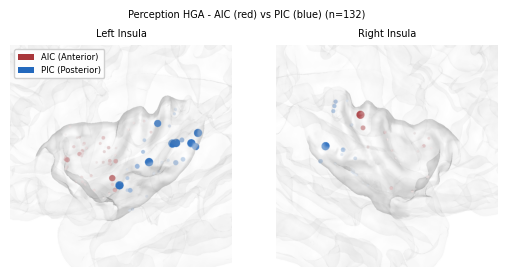

In [22]:
# Brain surface anatomy uses aparc.a2009s insula labels; electrode ROI comes from Hammers (AIC/PIC).
labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',
    surf_name='pial',
    hemi='both', subjects_dir=recon_dir
)

insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)


def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None


lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

lh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

size_min, size_max = 8, 30


def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)


def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]

    for i in range(len(coords_proj)):
        pt = coords_proj[i:i + 1]
        hga = hga_vals[i]
        roi = roi_vals[i]

        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))
        else:
            color = 'gray'

        size = hga_to_size(hga, vmin, vmax, size_min, size_max)

        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
        )

if mask_lh.any():
    add_electrodes_with_hga_colored(
        lh_brain, cord[mask_lh], hga_values[mask_lh], roi_values[mask_lh],
        lh_tree, lh_pial_coords, size_min, size_max,
    )

if mask_rh.any():
    add_electrodes_with_hga_colored(
        rh_brain, cord[mask_rh], hga_values[mask_rh], roi_values[mask_rh],
        rh_tree, rh_pial_coords, size_min, size_max,
    )

lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula", fontsize=fontsize)

legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)'),
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize - 1, framealpha=0.9)

plt.suptitle("Perception HGA - AIC (red) vs PIC (blue) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)

plt.savefig(f'../img/fig2/fig2_AIC_PIC_spatial_{phase}.svg', dpi=300, bbox_inches='tight')
plt.show()


## Panel C: Channel heatmaps (AIC + PIC)


In [14]:
def plot_roi_heatmap(roi, hemi='L', cmap=reds):
    phases = ['stimulus', 'delay', 'go', 'response']

    heatmap_subset = HGAs[
        (HGAs.description == 'Repeat')
        & (HGAs.modality == 'sound')
        & (HGAs.roi == roi)
        & (HGAs.subject != 'D0121')
    ]

    agg_data = heatmap_subset.groupby(['channel', 'time', 'phase']).agg({
        'value': 'mean',
        'mask': lambda x: x.any(),
    }).reset_index()

    agg_data.loc[~agg_data['mask'], 'value'] = np.nan

    max_channels = 0
    phase_channel_map = {}
    for phase in phases:
        phase_data = agg_data[agg_data.phase == phase]
        sig_channels = phase_data[phase_data['mask'] == True]['channel'].unique()
        first_sig_times = []
        for ch in sig_channels:
            ch_data = phase_data[phase_data.channel == ch]
            sig_times = ch_data[ch_data['mask'] == True]['time'].values
            if len(sig_times) > 0:
                first_sig_times.append((ch, sig_times.min()))
            else:
                first_sig_times.append((ch, np.inf))
        sorted_channels = [ch for ch, _ in sorted(first_sig_times, key=lambda x: x[1])]
        phase_channel_map[phase] = sorted_channels
        max_channels = max(max_channels, len(sorted_channels))

    fig, axes = plt.subplots(
        nrows=1, ncols=len(phases),
        figsize=(2.5 * len(phases) * cm, float(0.02 * max_channels * cm)),
    )

    for ax, phase in zip(axes, phases):
        sorted_channels = phase_channel_map[phase]
        phase_data = agg_data[agg_data.phase == phase]

        if len(sorted_channels) == 0:
            ax.text(0.5, 0.5, 'No significant\nchannels',
                    ha='center', va='center', transform=ax.transAxes, fontsize=7)
            ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_ylim(0, max_channels)
            continue

        phase_data_filtered = phase_data[phase_data.channel.isin(sorted_channels)]
        pivot_data = phase_data_filtered.pivot(index='channel', columns='time', values='value')
        pivot_data = pivot_data.reindex(index=sorted_channels)

        da = xr.DataArray(
            pivot_data.values,
            coords={'channel': pivot_data.index, 'time': pivot_data.columns},
            dims=['channel', 'time'],
        )

        time_values = da.coords['time'].values.astype(float)
        if len(time_values) > 1:
            step = np.diff(time_values).mean()
        else:
            step = 0.01
        time_edges = np.concatenate(([time_values[0] - step / 2], time_values[:-1] + step / 2, [time_values[-1] + step / 2]))
        channel_edges = np.arange(len(sorted_channels) + 1)

        T, C = np.meshgrid(time_edges, channel_edges)

        ax.pcolormesh(T, C, da.values, cmap=cmap, vmin=0, vmax=1.5, shading='auto', rasterized=True)

        sns.despine(ax=ax, offset=0, trim=False)
        ax.spines['left'].set_visible(False)
        ax.set_xticks([-1, 0, 1])
        ax.set_xticklabels(['-1', '0', '1'], fontsize=7)
        ax.set_yticks([])
        ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
        ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
        ax.set_ylim(0, max_channels)

        if ax == axes[0]:
            ax.set_ylabel(f'{roi} {hemi}H Channels (n={len(sorted_channels)})', fontsize=7)
        else:
            ax.set_ylabel('', fontsize=7)

    plt.suptitle(f'{roi} {hemi}', fontsize=8)
    # plt.savefig(f'../img/fig2/heatmap_{roi}_{hemi}_channels.svg', dpi=300, bbox_inches='tight')
    plt.show()


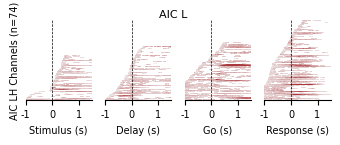

In [15]:
plot_roi_heatmap('AIC', hemi='L', cmap=reds)

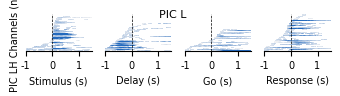

In [16]:
plot_roi_heatmap('PIC', hemi='L', cmap=blues)
